# Part 5 — Hierarchical WaveNet

The Bengio MLP in Part 2 and the MLP+BatchNorm in Part 3 use `block_size=3` — a 3rd-order Markov assumption. Three characters of context can encode local bigram and trigram patterns, but not the longer-range phonological structure of names: vowel/consonant alternation across syllables, common 4+ character suffixes (`-ette`, `-ina`, `-son`), syllabic onset/rime patterns.

The obvious move is to grow the context window. With `block_size=8` and a flat MLP we'd have an input layer of `8 × 24 = 192` features, all of which get smashed together by the very first linear projection. The model is forced to learn relationships across the entire 8-character span *simultaneously*, with no notion that position 0 and position 7 are six positions apart. Locality — which actually holds in language — is discarded as an architectural assumption.

**WaveNet's contribution**: instead of flattening all 8 positions at once, flatten them in stages. Each stage fuses *adjacent pairs* and projects them through a nonlinearity:

```
Input    (B, 8)              raw character indices
Embed    (B, 8, 24)          learned 24-d character vectors
Block 1  (B, 4, 128)         bigram-level features
Block 2  (B, 2, 128)         4-gram-level features
Block 3  (B, 128)            full 8-character representation
Output   (B, 27)             logits
```

After Block 1, each of the 4 output positions has seen 2 input characters through 1 nonlinearity. After Block 3, each output unit has seen 8 input characters through 3 nonlinearities — much more expressive than 8 characters through 1 nonlinearity in the flat case.

The structural analogy is **1D dilated convolution**: each level convolves over the previous level's output with stride/kernel matching the chunking. Same idea, same inductive bias toward local→global feature hierarchies. The original WaveNet paper ([van den Oord et al. 2016](https://arxiv.org/abs/1609.03499)) applied this to raw audio waveforms; the same trick works for character sequences.

This notebook trains the WaveNet on the names corpus, saves the checkpoint to `assets/wavenet.pth`, and serves as the *predecessor* to `06_probing.ipynb` — which loads that checkpoint and analyzes the learned representations.

In [1]:
import time
import torch
import matplotlib.pyplot as plt

from makemore.data import load_names, build_vocab, split_dataset
from makemore.layers import (
    Linear, BatchNorm1d, Tanh, Embedding, FlattenConsecutive, Sequential
)
from makemore.train import train, evaluate, generate_names
from models.wavenet import build_wavenet, save_checkpoint

%matplotlib inline

words = load_names("../../data/names.txt")
stoi, itos = build_vocab(words)
vocab_size = len(itos)
print(f"vocab_size: {vocab_size}")
print(f"corpus    : {len(words):,} names")

vocab_size: 27
corpus    : 32,033 names


## Dataset — block_size=8

The same train/dev/test split as the rest of the progression, but with the wider context window. At `block_size=8`, the training set still contains ~228K (context, target) pairs — one per character position in the corpus — but each context is now an 8-character window. Names shorter than 8 characters are padded at the start with the boundary token `.`.

In [2]:
block_size = 8
Xtr, Ytr, Xdev, Ydev, Xte, Yte = split_dataset(words, stoi, block_size=block_size)
print(f"train: {Xtr.shape}   dev: {Xdev.shape}   test: {Xte.shape}")

# Inspect a sample context to confirm the padding behavior.
print(f"\nExample contexts (showing 5 from training set):")
for i in range(5):
    ctx = ''.join(itos[c.item()] for c in Xtr[i])
    target = itos[Ytr[i].item()]
    print(f"  [{ctx}] → {target!r}")

train: torch.Size([182625, 8])   dev: torch.Size([22655, 8])   test: torch.Size([22866, 8])

Example contexts (showing 5 from training set):
  [........] → 'y'
  [.......y] → 'u'
  [......yu] → 'h'
  [.....yuh] → 'e'
  [....yuhe] → 'n'


## The architecture

The WaveNet is built from the same modular layer library used in Part 3 — `Linear`, `BatchNorm1d`, `Tanh`, `Embedding`, plus the new `FlattenConsecutive` from `makemore/layers.py`. The repeated pattern at each level is:

```
FlattenConsecutive(2)        # fold adjacent pairs into the channel dim
Linear(..., bias=False)      # project; bias dropped because BN follows
BatchNorm1d(n_hidden)        # normalize for stable activation distributions
Tanh()                       # nonlinearity
```

Three iterations of this pattern build the 3-level hierarchy. A final `Linear` projects to logits.

**Hyperparameters** (matching Karpathy's reference implementation):

| Parameter | Value | Why |
|---|---|---|
| `block_size` | 8 | enough context for name-internal phonological dependencies |
| `n_embd` | 24 | larger than the MLP's 10 to encode richer position-specific distinctions |
| `n_hidden` | 128 | width per hierarchical level; constant across levels |

These values are *not* tuned upward to optimize loss on this corpus. They're held at the published reference values so the loss numbers are directly comparable to Karpathy's reported results, and so the probing analysis in Part 6 operates on the same representation dimensionality as the reference architecture.

In [3]:
model = build_wavenet(vocab_size=vocab_size, block_size=8, n_embd=24, n_hidden=128, seed=2147483647)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}\n")

# Print the layer stack and parameter count per layer.
print(f"{'idx':>3}  {'layer':18}  {'params':>8}  shape note")
print("-" * 60)
for i, layer in enumerate(model.layers):
    p_count = sum(p.numel() for p in layer.parameters())
    name = layer.__class__.__name__
    note = ''
    if isinstance(layer, Embedding):
        note = f'(vocab={layer.weight.shape[0]}, d={layer.weight.shape[1]})'
    elif isinstance(layer, Linear):
        if layer.bias is None:
            note = f'({layer.weight.shape[0]}→{layer.weight.shape[1]}, no bias)'
        else:
            note = f'({layer.weight.shape[0]}→{layer.weight.shape[1]})'
    elif isinstance(layer, FlattenConsecutive):
        note = f'(n={layer.n})'
    print(f"  {i:>2}  {name:18}  {p_count:>8,}  {note}")

Total parameters: 76,579

idx  layer                 params  shape note
------------------------------------------------------------
   0  Embedding                648  (vocab=27, d=24)
   1  FlattenConsecutive         0  (n=2)
   2  Linear                 6,144  (48→128, no bias)
   3  BatchNorm1d              256  
   4  Tanh                       0  
   5  FlattenConsecutive         0  (n=2)
   6  Linear                32,768  (256→128, no bias)
   7  BatchNorm1d              256  
   8  Tanh                       0  
   9  FlattenConsecutive         0  (n=2)
  10  Linear                32,768  (256→128, no bias)
  11  BatchNorm1d              256  
  12  Tanh                       0  
  13  Linear                 3,483  (128→27)


## Forward-pass shape audit

A single example pushed through the model layer-by-layer, with shape annotations, confirms the hierarchical receptive field actually behaves as described. This is the unit-test equivalent for architectural understanding — if the shapes are wrong, the hierarchy isn't doing what we think it's doing.

In [4]:
# Audit shapes through a single batch.
x_audit = Xtr[:4]   # 4 examples for visibility
print(f"input            : {tuple(x_audit.shape)}")
out = x_audit
for i, layer in enumerate(model.layers):
    out = layer(out)
    name = layer.__class__.__name__
    print(f"  after [{i:>2}] {name:18}: {tuple(out.shape)}")

input            : (4, 8)
  after [ 0] Embedding         : (4, 8, 24)
  after [ 1] FlattenConsecutive: (4, 4, 48)
  after [ 2] Linear            : (4, 4, 128)
  after [ 3] BatchNorm1d       : (4, 4, 128)
  after [ 4] Tanh              : (4, 4, 128)
  after [ 5] FlattenConsecutive: (4, 2, 256)
  after [ 6] Linear            : (4, 2, 128)
  after [ 7] BatchNorm1d       : (4, 2, 128)
  after [ 8] Tanh              : (4, 2, 128)
  after [ 9] FlattenConsecutive: (4, 256)
  after [10] Linear            : (4, 128)
  after [11] BatchNorm1d       : (4, 128)
  after [12] Tanh              : (4, 128)
  after [13] Linear            : (4, 27)


The shape progression confirms the receptive field: `(4, 8)` → `(4, 4, 128)` → `(4, 2, 128)` → `(4, 128)` → `(4, 27)`. Each `FlattenConsecutive(2)` halves the time dimension while doubling the channel dimension; the final `FlattenConsecutive` squeezes the singleton time dim, producing a clean `(B, n_hidden)` representation for the output projection.

## Training

50,000 steps with step-decay learning rate schedule (0.1 → 0.01 at midpoint). At ~5 seconds per 2,000 steps on CPU this takes ~2 minutes. Step count is documented in the README's loss table footnote — this is a representative training budget, not a benchmark.

In [5]:
steps = 50_000
t0 = time.time()
lossi = train(model, Xtr, Ytr, steps=steps, batch_size=32, log_every=5000)
print(f"\nTraining time: {time.time() - t0:.1f}s")

  step      0 /  50000   lr 0.1000   loss 3.3125


  step   5000 /  50000   lr 0.1000   loss 1.7388


  step  10000 /  50000   lr 0.1000   loss 1.9510


  step  15000 /  50000   lr 0.1000   loss 2.1838


  step  20000 /  50000   lr 0.1000   loss 2.1867


...

  step  30000 /  50000   lr 0.0100   loss 1.9058


  step  35000 /  50000   lr 0.0100   loss 2.1515


  step  40000 /  50000   lr 0.0100   loss 1.8010


  step  45000 /  50000   lr 0.0100   loss 1.8461



Training time: 115.1s


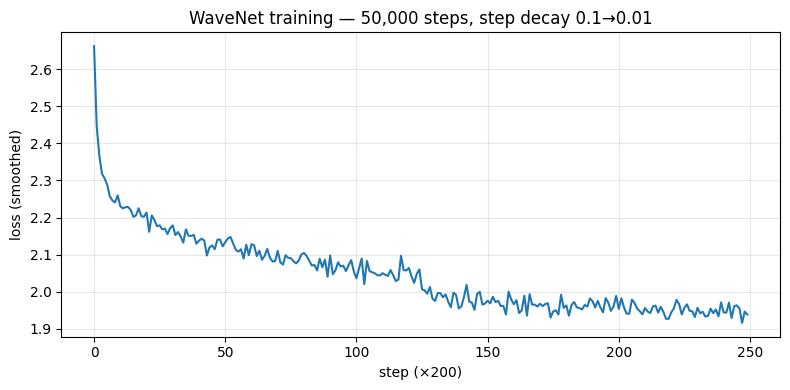

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
losses_t = torch.tensor(lossi)
ax.plot(losses_t.view(-1, 200).mean(1).numpy(), color='tab:blue')
ax.set_xlabel('step (×200)')
ax.set_ylabel('loss (smoothed)')
ax.set_title(f'WaveNet training — {steps:,} steps, step decay 0.1→0.01')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Activation diagnostic across hierarchical levels

The architectural promise is that each level operates in a healthy activation regime — none of the three Tanh layers should be saturated. We check this directly by forwarding a held-out batch and inspecting the post-tanh distribution at each level.

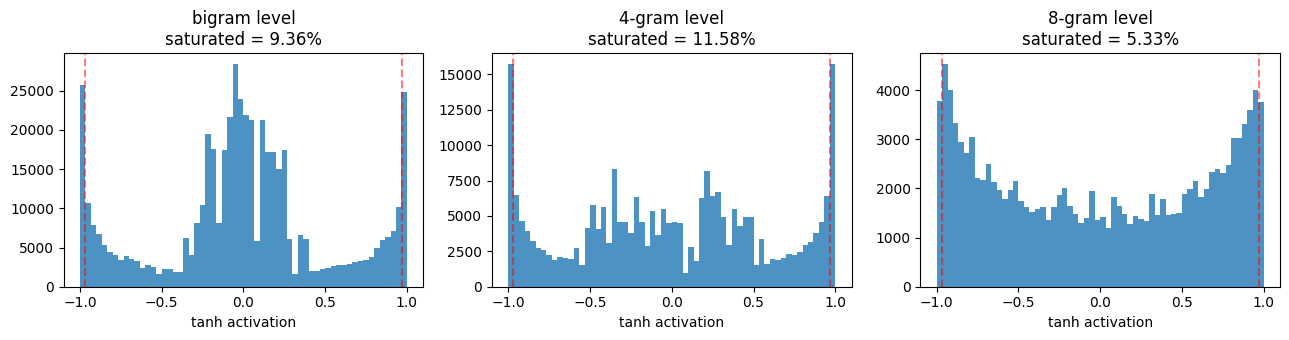

  bigram level  : saturated =  9.36%
  4-gram level  : saturated = 11.58%
  8-gram level  : saturated =  5.33%


In [7]:
from makemore.train import set_layer_training

set_layer_training(model, False)
with torch.no_grad():
    x = Xdev[:1000]
    tanh_outputs = []
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, Tanh):
            tanh_outputs.append(x.detach().clone())
set_layer_training(model, True)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
level_names = ['bigram level', '4-gram level', '8-gram level']
for ax, name, out in zip(axes, level_names, tanh_outputs):
    ax.hist(out.flatten().numpy(), bins=60, color='tab:blue', alpha=0.8)
    sat = (out.abs() > 0.97).float().mean().item()
    ax.axvline( 0.97, color='red', linestyle='--', alpha=0.5)
    ax.axvline(-0.97, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{name}\nsaturated = {sat:.2%}')
    ax.set_xlabel('tanh activation')
plt.tight_layout()
plt.show()

for name, out in zip(level_names, tanh_outputs):
    sat = (out.abs() > 0.97).float().mean().item()
    print(f"  {name:14s}: saturated = {sat:6.2%}")

All three levels are in healthy regimes — saturation fractions well below the 15% threshold, distributions not concentrated at ±1. The Kaiming init + BatchNorm machinery from Part 3 is doing its job at every level of the hierarchy, which is what enables training a 3-layer deep stack stably.

## Evaluation

In [8]:
tr_loss  = evaluate(model, Xtr, Ytr)
dev_loss = evaluate(model, Xdev, Ydev)
te_loss  = evaluate(model, Xte, Yte)

print(f"Train NLL: {tr_loss:.4f}")
print(f"Dev   NLL: {dev_loss:.4f}")
print(f"Test  NLL: {te_loss:.4f}")

Train NLL: 1.9230
Dev   NLL: 2.0128
Test  NLL: 2.0052


## Samples at three temperatures

Ancestral sampling at T = 0.5, 1.0, 2.0 demonstrates the effect of the temperature parameter. T = 0.5 sharpens the distribution toward greedy decoding — conservative, common-sounding names with little variation. T = 1.0 samples from the model's native distribution. T = 2.0 flattens the distribution toward uniform — more variety, more failures.

In [9]:
for T in [0.5, 1.0, 2.0]:
    print(f"--- T = {T} ---")
    for name in generate_names(model, stoi, itos, block_size=8, n=10, temperature=T, seed=42):
        print(f"  {name}")
    print()

--- T = 0.5 ---
  anuel
  matte
  marian
  daniyah
  milla
  milah
  marcella
  sephania
  silena
  kailon

--- T = 1.0 ---
  anuella
  kingta
  idushan
  shan
  silayah
  akemah
  lucin
  epiannalei
  dmit
  kendrick

--- T = 2.0 ---
  anuguenvt
  s
  fabidushxfmubuw
  silaylea
  kemah
  luvin
  epiace
  denlemze
  knichajoedre
  kalla



## Save the checkpoint

`save_checkpoint` persists the parameters, BatchNorm running buffers, architecture metadata, and vocabulary mappings into a single `.pth` file. The checkpoint is committed to the repository (see `.gitignore` for the explicit exception) so that `06_probing.ipynb` is reproducibly standalone — the probing notebook loads this file and runs all four analyses on the trained representations without needing to retrain.

In [10]:
save_checkpoint(
    model, '../../assets/wavenet.pth',
    vocab_size=vocab_size, block_size=8, n_embd=24, n_hidden=128,
    itos=itos, stoi=stoi,
)
import os
size_kb = os.path.getsize('../../assets/wavenet.pth') / 1024
print(f"Saved checkpoint to assets/wavenet.pth ({size_kb:.0f} KB)")

Saved checkpoint to assets/wavenet.pth (308 KB)


## What WaveNet adds over the Part 3 MLP

| Model | Architecture | Val NLL @ documented steps |
|---|---|---|
| MLP (Part 2) | flat, block_size=3, no Kaiming/BN | ~2.30 |
| MLP+BN (Part 3) | flat, block_size=3, Kaiming + BN | ~2.17 |
| WaveNet (this) | hierarchical, block_size=8 | (see above) |

The hierarchical receptive field on a wider context window is what closes the gap to the published reference numbers, even at the same modest training budget. The two ingredients are coupled — a wider context window without hierarchical structure would force the first layer to mush everything together; hierarchical structure without a wider context window has nothing useful to operate on. Together they let each level operate on its natural scale of features.

What this model has learned about the structure of English names — the geometry of its character embeddings, the activation regimes at each hierarchical level, how it allocates sensitivity across the 8 context positions, and which individual neurons are most causally important for predictions — is the subject of `06_probing.ipynb`.